In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("D:\\Download\\archive\\netflix_customer_churn.csv")

In [3]:
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [5]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [6]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

In [7]:
df = df.dropna()

In [9]:
from sklearn.preprocessing import LabelEncoder

le_subscription = LabelEncoder()
le_payment = LabelEncoder()

# Only encode actual categorical (text) columns
df['subscription_type'] = le_subscription.fit_transform(df['subscription_type'])
df['payment_method'] = le_payment.fit_transform(df['payment_method'])

# number_of_profiles is already a number — no encoding needed
# just make sure it's the right type
df['number_of_profiles'] = df['number_of_profiles'].astype(int)

In [11]:
df = df.drop('customer_id', axis = 1)

In [12]:
df.head(10)

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,0,14.73,29,Africa,TV,8.99,1,3,1,0.49,Action
1,47,Other,2,0.70,19,Europe,Mobile,13.99,1,3,5,0.03,Sci-Fi
2,27,Female,2,16.32,10,Asia,TV,13.99,0,1,2,1.48,Drama
3,53,Other,1,4.51,12,Oceania,TV,17.99,1,1,2,0.35,Horror
4,56,Other,2,1.89,13,Africa,Mobile,13.99,1,1,2,0.13,Action
5,58,Female,2,13.80,26,Oceania,Mobile,13.99,0,2,3,0.51,Action
6,48,Other,0,13.83,20,Asia,TV,8.99,0,3,5,0.66,Romance
7,51,Male,0,14.30,56,Europe,Mobile,8.99,1,3,1,0.25,Action
8,45,Other,0,9.98,10,Asia,Mobile,8.99,0,4,3,0.91,Romance
9,32,Other,1,2.22,34,Europe,TV,17.99,1,2,1,0.06,Drama


In [15]:
# These columns are still text — model can't read text
df = pd.get_dummies(df, columns=[
    'gender',
    'region',
    'device',
    'favorite_genre'
], drop_first=True)

print(df.shape)
print(df.columns.tolist())

(5000, 26)
['age', 'subscription_type', 'watch_hours', 'last_login_days', 'monthly_fee', 'churned', 'payment_method', 'number_of_profiles', 'avg_watch_time_per_day', 'gender_Male', 'gender_Other', 'region_Asia', 'region_Europe', 'region_North America', 'region_Oceania', 'region_South America', 'device_Laptop', 'device_Mobile', 'device_TV', 'device_Tablet', 'favorite_genre_Comedy', 'favorite_genre_Documentary', 'favorite_genre_Drama', 'favorite_genre_Horror', 'favorite_genre_Romance', 'favorite_genre_Sci-Fi']


In [17]:
# Feature 1: Is the user inactive for a long time?
df['is_inactive'] = (df['last_login_days'] > 30).astype(int)
# Why? Someone who hasn't logged in for 30+ days is a strong churn risk
# 1 = inactive, 0 = active

# Feature 2: Fee per profile — are they getting value for money?
df['fee_per_profile'] = df['monthly_fee'] / df['number_of_profiles']
# Why? A family sharing 5 profiles at $17.99 gets great value
# A single user paying $17.99 for 1 profile may feel it's too expensive — churn risk

# Feature 3: Watch intensity
df['watch_intensity'] = df['watch_hours'] / (df['avg_watch_time_per_day'] + 0.01)
# Why? Captures engagement quality — not just total hours but how regularly they watch
# +0.01 avoids division by zero error

print("New shape:", df.shape)
print("\nNew features added:")
print(df[['is_inactive', 'fee_per_profile', 'watch_intensity']].head(5))

New shape: (5000, 29)

New features added:
   is_inactive  fee_per_profile  watch_intensity
0            0            8.990        29.460000
1            0            2.798        17.500000
2            0            6.995        10.953020
3            0            8.995        12.527778
4            0            6.995        13.500000


In [18]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop(columns=['churned'])
y = df['churned']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (5000, 28)
y shape: (5000,)

Target distribution:
churned
1    2515
0    2485
Name: count, dtype: int64


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing, 80% for training
    random_state=42,     # ensures same split every time you run
    stratify=y           # keeps churn ratio same in both splits
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (4000, 28)
Testing size: (1000, 28)


In [21]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 4.6 MB/s eta 0:00:23
    --------------------------------------- 1.8/101.7 MB 5.3 MB/s eta 0:00:19
   - -------------------------------------- 3.1/101.7 MB 5.9 MB/s eta 0:00:17
   -- ------------------------------------- 5.5/101.7 MB 7.3 MB/s eta 0:00:14
   --- ------------------------------------ 7.9/101.7 MB 8.1 MB/s eta 0:00:12
   --- ------------------------------------ 10.0/101.7 MB 8.4 MB/s eta 0:00:11
   ---- ----------------------------------- 10.5/101.7 MB 7.8 MB/s eta 0:00:12
   ---- ----------------------------------- 11.5/101.7 MB 7.2 MB/s eta 0:00:13
   ----- ---------------------------------- 14.4/101.7 MB 7.8 MB/s eta 0:00:12
   ------ --------------------------------- 15.7/101.7 MB 7.6 MB/s eta 0:00:12
   ------ --------------------------------- 16.8/101.7 MB 7.4 MB/s eta 0:00:12
   ------- -------------------------------- 18.4/101.7 MB 7.4 MB/

In [22]:
from xgboost import XGBClassifier

# Build the model
model = XGBClassifier(
    n_estimators=100,      # number of trees to build
    learning_rate=0.1,     # how much each tree corrects the previous
    max_depth=5,           # how deep each tree can grow
    random_state=42        # reproducibility
)

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [23]:
# Predict on test data
y_pred = model.predict(X_test)

# Predict probability of churning (0 to 1)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("First 10 predictions:", y_pred[:10])
print("First 10 churn probabilities:", y_pred_proba[:10].round(2))

First 10 predictions: [0 1 0 1 1 1 1 1 0 0]
First 10 churn probabilities: [0.   0.99 0.04 1.   1.   0.99 0.99 1.   0.03 0.08]


In [24]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Basic accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# AUC-ROC Score
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC-ROC Score:", round(auc, 3))

Accuracy: 99.4 %

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       497
           1       1.00      0.99      0.99       503

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000

AUC-ROC Score: 1.0


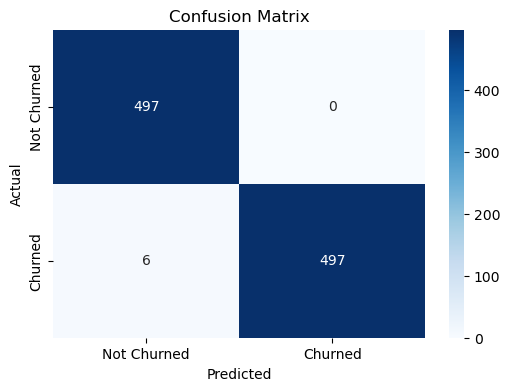

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

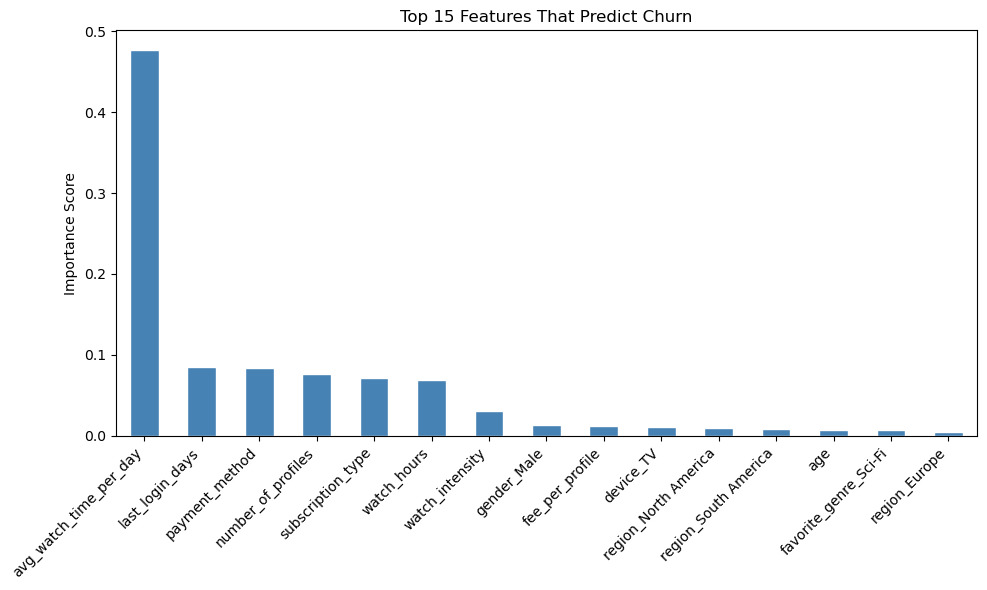


Top 10 features:
avg_watch_time_per_day    0.477105
last_login_days           0.084768
payment_method            0.083320
number_of_profiles        0.076209
subscription_type         0.071865
watch_hours               0.068569
watch_intensity           0.030653
gender_Male               0.013741
fee_per_profile           0.012566
device_TV                 0.010487
dtype: float32


In [26]:
import matplotlib.pyplot as plt

# Get feature importance from the model
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Plot top 15 most important features
plt.figure(figsize=(10, 6))
importance[:15].plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 Features That Predict Churn')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importance[:10])

In [27]:
!pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 593.8 kB/s  0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   --------

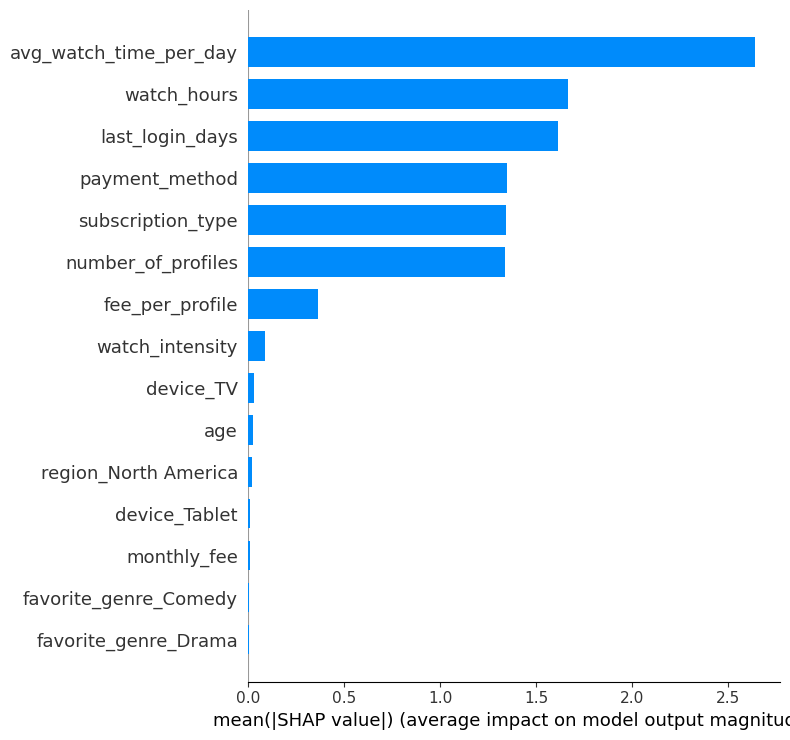

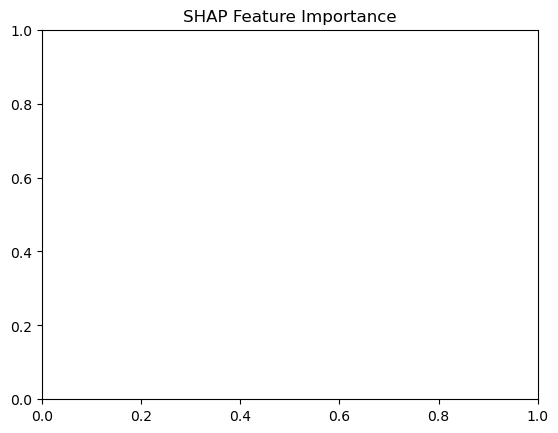

In [28]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot 1 — Summary plot (most important)
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15)
plt.title('SHAP Feature Importance')
plt.show()

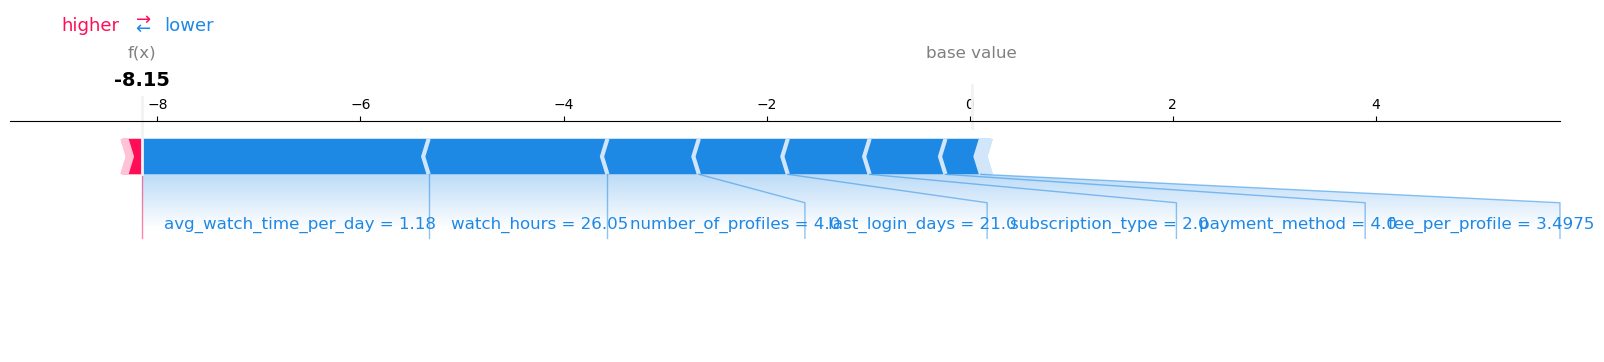

In [29]:
# Pick one user — let's look at user index 0
shap.initjs()

# Explain why user 0 was predicted as churned or not
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0],
    matplotlib=True
)
plt.show()

In [30]:
import joblib

# Save the model to a file
joblib.dump(model, 'churn_model.pkl')

print("Model saved successfully as churn_model.pkl!")

Model saved successfully as churn_model.pkl!


In [31]:
# Load the model back
loaded_model = joblib.load('churn_model.pkl')

# Verify it works
test_pred = loaded_model.predict(X_test)
print("Model loaded successfully!")
print("Accuracy check:", round(accuracy_score(y_test, test_pred) * 100, 2), "%")

Model loaded successfully!
Accuracy check: 99.4 %


In [32]:
def predict_churn(user_data):
    """
    Predict if a user will churn or not.
    
    user_data = dictionary of user details
    """
    # Convert input to dataframe
    user_df = pd.DataFrame([user_data])
    
    # Make sure columns match training data
    user_df = user_df.reindex(columns=X_train.columns, fill_value=0)
    
    # Predict
    churn_prob = loaded_model.predict_proba(user_df)[:, 1][0]
    churn_pred = loaded_model.predict(user_df)[0]
    
    print(f"\n{'='*40}")
    print(f"Churn Prediction Result")
    print(f"{'='*40}")
    print(f"Will this user churn? {'YES' if churn_pred == 1 else 'NO'}")
    print(f"Churn Probability: {round(churn_prob * 100, 1)}%")
    
    if churn_prob >= 0.7:
        print("Risk Level: HIGH — Send discount offer immediately!")
    elif churn_prob >= 0.4:
        print("Risk Level: MEDIUM — Send personalized recommendations")
    else:
        print("Risk Level: LOW — User is happy, no action needed")
    print(f"{'='*40}")
    
    return churn_prob

In [33]:
# Example: a user who hasn't logged in for 45 days
# and watches very little
sample_user = {
    'age': 28,
    'watch_hours': 2.5,
    'last_login_days': 45,
    'monthly_fee': 17.99,
    'number_of_profiles': 1,
    'avg_watch_time_per_day': 0.08,
    'subscription_type': 1,   # use the encoded value
    'payment_method': 2,
    'is_inactive': 1,
    'fee_per_profile': 17.99,
    'watch_intensity': 31.25
}

predict_churn(sample_user)


Churn Prediction Result
Will this user churn? YES
Churn Probability: 99.9000015258789%
Risk Level: HIGH — Send discount offer immediately!


np.float32(0.99940217)